本レッスンの実習では、 TensorFlow（テンソルフロー）と Keras（ケラス）というパッケージライブラリを使います。
TensorFlow はGoogleが開発したディープラーニングのライブラリです。現在もっとも多く使われているディープラーニングのライブラリの1つ

深層学習では、多数の層を組み合わせてモデルを作成します。深層学習のプログラムを作る場合、TensorFlowで用意されている数多くの層に関する知識を得て、自身の手で層を組み合わせてプログラムを作る必要があり、手軽に深層学習を体験できません。そこで、転移学習 の技術を利用
TensorFlowが持つ image_dataset_from_directory() を実行し、データを読み込みます。最初の引数には、画像データのあるフォルダのパスを指定

In [ ]:
# 訓練データとテストデータの画像を読み込む
# （サイズは縦横224pxにリサイズする）
import tensorflow as tf

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "nagaoka_gis/train",
    image_size=(224, 224), #MobileNetV2 モデルでは、扱える画像ファイルの縦横のサイズが決まっていて、以下のいずれかの長さで縦横同じ（正方形の画像）にする必要があります,224px にリサイズ
    label_mode="binary", #label_modeには、今回どのような分類を行なうかを指定,今回は、ゴルフ場が写っているかの有無を判定する分類のため、2値分類（binary）としています
    batch_size=32, #batch_sizeは、1回の学習で何枚の画像を使うかを指定,デフォルトの32を明示的に指定
    shuffle=True #shuffleは、画像を読み込む順番をランダムにするかどうかを指定
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "nagaoka_gis/test",
    image_size=(224, 224),
    label_mode="binary",
    batch_size=32,
    shuffle=False #テストデータは並べ替える必要性がないため、順番通りに読み込む（False）形
)

In [2]:
#image_dataset_from_directory() の出力結果は、特殊な型をしたデータとなっており、そのままでは中身を確認できません
# データの詳細を表示する
list(train_dataset.as_numpy_iterator())[0] #要素数が2のリストとして内容を確認

(array([[[[131.05357 , 135.05357 , 121.053566],
          [125.51786 , 128.51785 , 119.23215 ],
          [129.43622 , 134.79593 , 126.71684 ],
          ...,
          [ 62.05375 ,  83.56136 ,  55.71443 ],
          [ 45.65057 ,  70.17355 ,  47.931152],
          [ 35.67076 ,  59.47433 ,  40.67076 ]],
 
         [[131.49236 , 135.49236 , 121.49235 ],
          [136.01785 , 139.01785 , 129.73215 ],
          [130.47704 , 133.2551  , 123.21938 ],
          ...,
          [ 21.015375,  42.53323 ,  28.451572],
          [ 27.783445,  40.783447,  32.81916 ],
          [ 11.482199,  23.61995 ,  19.946503]],
 
         [[134.68878 , 138.68878 , 124.688774],
          [135.70409 , 138.70409 , 129.41838 ],
          [162.10204 , 163.93367 , 151.01785 ],
          ...,
          [ 21.663544,  45.403328,  30.293589],
          [ 40.364857,  58.64295 ,  46.872482],
          [ 10.204059,  27.793344,  19.20406 ]],
 
         ...,
 
         [[ 67.4874  ,  93.4874  ,  68.4874  ],
          [ 51.334

最初の要素は画像の色のデータです。一般的なカラー画像は、ピクセルごとに色の強さのデータを持っています。カラー画像を読み込むと、画像の高さ（縦） x 画像の幅（横） x 3（RGB） という3次元配列の形式のデータになります。各色は0から255までの範囲内の数値型のデータです。今回配布している航空写真データは、1つの画像につき 600 x 800 x 3 = 1440000 個の配列要素が存在することになります
2つ目の要素はラベル（正解の値）です。読み込まれた画像ごとに、ゴルフ場が写っているかによって0か1の値が格納.
0と1が何を指しているかは、以下のように class_names 属性を確認,今回の場合、no が0、yes は1

In [3]:
# 分類名（no／yes）をリストとして格納する
class_names = train_dataset.class_names
class_names

['no', 'yes']

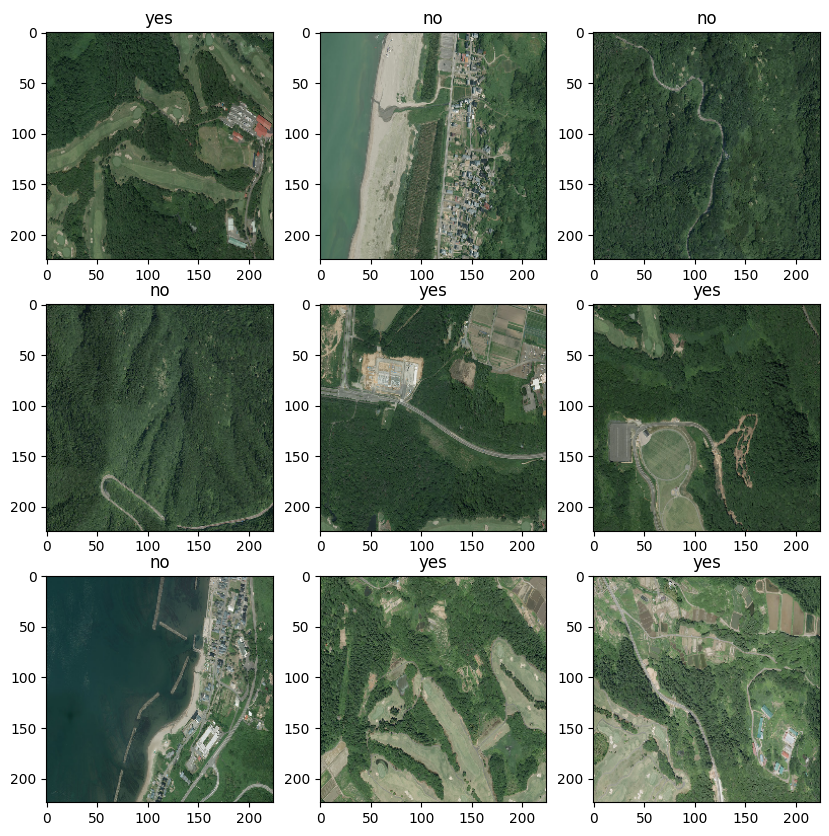

In [4]:
# 訓練データの一部を表示して確認
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy().astype("uint8")[0]])

TensorFlowの機能を使って、データの水増しを行ないます。今回は、元の画像に対して、以下のような処理を行なって、画像を水増し
tf.image が持つメソッドを利用することで実現します。まずは、それぞれの水増しを行なうための関数を定義します。rot90() の k は、90度回転する回数の指定で、デフォルトは1回です。k=2 で180度、k=3 で270度回転


In [2]:
# 画像の水増しをする関数の定義
def flip_left_right(image, label):   # 左右反転
    image = tf.image.flip_left_right(image)
    return image, label

def flip_up_down(image, label):      # 上下反転
    image = tf.image.flip_up_down(image)
    return image, label

def rot90(image, label):             # 反時計回りに90度回転
    image = tf.image.rot90(image)
    return image, label

def rot180(image, label):            # 反時計回りに180度回転
    image = tf.image.rot90(image, k=2)
    return image, label

def rot270(image, label):            # 反時計回りに270度回転
    image = tf.image.rot90(image, k=3)
    return image, label

この各関数を実行し、水増しを行ないます。train_dataset が持つ map() メソッドを使うことで、データセット内にあるすべての画像に対して、水増しが行なわれます。map() メソッドの引数には、適用する関数名を指定します。また、map() は非破壊的メソッドのため、新しい変数を用意して、出力結果を格納します。

In [3]:
# 画像の水増し処理の実行
train_dataset_lr     = train_dataset.map(flip_left_right)
train_dataset_ud     = train_dataset.map(flip_up_down)
train_dataset_rot90  = train_dataset.map(rot90)
train_dataset_rot180 = train_dataset.map(rot180)
train_dataset_rot270 = train_dataset.map(rot270)

NameError: name 'train_dataset' is not defined

In [7]:
# 水増ししたデータを訓練データに追加する
#concatenate() メソッドを使うことで、データセットを結合できます。concatenate() メソッドの引数には、結合したいデータセットを指定
train_dataset = train_dataset.concatenate(train_dataset_lr)
train_dataset = train_dataset.concatenate(train_dataset_ud)
train_dataset = train_dataset.concatenate(train_dataset_rot90)
train_dataset = train_dataset.concatenate(train_dataset_rot180)
train_dataset = train_dataset.concatenate(train_dataset_rot270)

In [8]:
# データをシャッフルする
train_dataset = train_dataset.shuffle(32) #shuffle() メソッドの引数には、基本的に image_dataset_from_directory() の batch_size 引数で指定した値と同じものを指定

In [1]:
# 訓練データの一部を表示して確認
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy().astype("uint8")[0]])

NameError: name 'plt' is not defined